# FinalProjectV4 — Localization Overdrive

**YOLOv12l** (Large) @ **896px** + EfficientNet-B0 ensemble + **Grad-CAM Heatmaps**.

## What's new vs V3
1. **YOLOv12l** — larger model than V3's yolo12m, optimized for T4 GPU memory
2. **896px resolution** — nearly 2x more pixels than V3's 640px for fuzzy pneumonia borders
3. **RSNA 3-radiologist consensus** — WBF merges multiple annotations into gold-standard boxes
4. **Reduced Mosaic (0.1), added Mixup (0.2)** — better anatomical context preservation
5. **box=12.0** — 60% higher localization penalty for tighter bounding boxes
6. **Grad-CAM Heatmaps** — visual "focus area" maps showing where the model is looking


## 1. Environment Setup


In [1]:
%%capture
!pip install -q ultralytics==8.3.40 timm==1.0.11
!pip install -q albumentations==1.4.0 opencv-python pillow pandas pyarrow fastparquet
!pip install -q matplotlib seaborn distinctipy tabulate
!pip install -q lungmask SimpleITK pydicom imagehash
!pip install -q ensemble-boxes
!pip install -q torchmetrics scikit-learn scipy
!pip install -q grad-cam
!pip install -U ultralytics

In [2]:
import os, sys, json, math, random, hashlib, warnings, shutil, gc, time
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from pathlib import Path
from glob import glob
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

import cv2
cv2.setNumThreads(0)  # Core fix for Kaggle OpenCV deadlocks
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from distinctipy import distinctipy
import imagehash

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision

import albumentations as A
from albumentations.pytorch import ToTensorV2

import SimpleITK as sitk
from lungmask import LMInferer
from ultralytics import YOLO
import timm
from ensemble_boxes import weighted_boxes_fusion
from torchmetrics.detection import MeanAveragePrecision
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("All dependencies loaded")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All dependencies loaded


## 2. Configuration


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_GPUS = torch.cuda.device_count()
print(f"Device: {device} | GPUs: {NUM_GPUS}")

CLASS_NAMES = ["tumor_xray", "tuberculosis", "pneumonia"]
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

# ── V4: LOCALIZATION OVERDRIVE ──
# NOTE: yolo12x @ 1024 OOMs on T4 (attention scales quadratically).
# yolo12l @ 896 is the sweet spot: 2x more pixels than V3, fits in 15GB.
IMG_SIZE = 896               # V4: 896px (was 640) — max for yolo12l on T4
BATCH_SIZE = 6 if NUM_GPUS >= 2 else 3   # V4: fits yolo12l @ 896 on dual T4
EPOCHS = 100
PATIENCE = 25

MODEL_VARIANT = "yolo12l.pt"  # V4: LARGE (was yolo12m) — best attention model that fits T4
RUN_NAME = f"v4_{MODEL_VARIANT.replace('.pt','')}_{IMG_SIZE}"

PER_CLASS = {
    "tumor_xray":   {"area_cap_pct": 15.0, "conf_thr": 0.25, "wbf_iou": 0.55, "max_bboxes_img": 8},
    "tuberculosis": {"area_cap_pct": 15.0, "conf_thr": 0.20, "wbf_iou": 0.55, "max_bboxes_img": 15},
    "pneumonia":    {"area_cap_pct": 30.0, "conf_thr": 0.15, "wbf_iou": 0.60, "max_bboxes_img": 12},
}

USE_DATASETS = {
    "TBX11K": True, "VinDr_CXR": True, "RSNA_Pneumonia": True,
    "VinBigData_CXR": True, "ChestX_Det": True, "cxray14": True,
    "CXR_Lung_Node21": True, "SIIM_COVID19": True, "JSRT": True, "Shenzhen": False,
}

PROJECT_DIR = Path("/kaggle/working/finalprojectv4")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR  = PROJECT_DIR / "cache";       CACHE_DIR.mkdir(exist_ok=True)
CROP_DIR   = PROJECT_DIR / "lung_crops";  CROP_DIR.mkdir(exist_ok=True)
YOLO_DIR   = PROJECT_DIR / "yolo_dataset"; YOLO_DIR.mkdir(exist_ok=True)
RUNS_DIR   = PROJECT_DIR / "runs";        RUNS_DIR.mkdir(exist_ok=True)

CACHE_VERSION = "v4_3class_xray"
DF_CACHE   = CACHE_DIR / f"df_{CACHE_VERSION}.parquet"
NORM_CACHE = CACHE_DIR / f"norm_{CACHE_VERSION}.json"
SPLIT_CACHE = CACHE_DIR / f"split_{CACHE_VERSION}.json"
CROP_MANIFEST = CROP_DIR / "crop_manifest.json"
DATA_YAML = YOLO_DIR / "data.yaml"
STATE_FILE = CACHE_DIR / "cache_state.json"

FORCE_REBUILD_DF    = True
FORCE_REBUILD_CROPS = False
FORCE_REBUILD_YOLO  = True
FORCE_FRESH_TRAIN   = False    # V4 RESUME: look for last.pt from previous run

print(f"V4 Config: {MODEL_VARIANT} @ {IMG_SIZE}px | batch={BATCH_SIZE} | epochs={EPOCHS}")
print(f"NOTE: yolo12x@1024 OOMs on T4. Using yolo12l@896 (still 2x pixels vs V3's 640)")


Device: cuda | GPUs: 2
V4 Config: yolo12l.pt @ 896px | batch=6 | epochs=100
NOTE: yolo12x@1024 OOMs on T4. Using yolo12l@896 (still 2x pixels vs V3's 640)


## 2b. Copy V2 Cached Artifacts


In [4]:
SRC_V2 = None
for p in Path("/kaggle/input").rglob("finalprojectv4"):
    if "preprocessed-dataset" in p.parts:
        SRC_V2 = p
        break
if SRC_V2 is None:
    SRC_V2 = Path("/kaggle/input/datasets/michaelgetuu/preprocessed-dataset-v4/finalprojectv4") # Fallback

if SRC_V2.exists():
    src_crops = SRC_V2 / "lung_crops"
    if src_crops.exists() and not CROP_MANIFEST.exists():
        if CROP_DIR.exists(): shutil.rmtree(CROP_DIR)
        shutil.copytree(src_crops, CROP_DIR)
        print(" - lung_crops copied from V2")
    src_norm = SRC_V2 / "cache" / "norm_v4_3class_xray.json"
    if src_norm.exists():
        shutil.copy2(src_norm, NORM_CACHE); print(" - norm stats copied")
    src_df = SRC_V2 / "cache" / "df_v4_3class_xray.parquet"
    v2_df_path = CACHE_DIR / "df_v2_reference.parquet"
    if src_df.exists():
        shutil.copy2(src_df, v2_df_path); print(" - V2 df copied as reference")
    src_split = SRC_V2 / "cache" / "split_v4_3class_xray.json"
    if src_split.exists():
        shutil.copy2(src_split, SPLIT_CACHE); print(" - Split cache copied from V2")
    print("V2 artifacts reused!")
else:
    print("V2 source not found - will build from scratch")


 - lung_crops copied from V2
 - norm stats copied
 - V2 df copied as reference
 - Split cache copied from V2
V2 artifacts reused!


## 2c. Recover V4 Checkpoint (Resume Training)


In [5]:
# Look for last.pt from previous Kaggle run output
# When you "Save & Run" again, the previous output is accessible as input
_inp = Path("/kaggle/input")
_globs = []
if _inp.exists():
    _globs += list(_inp.glob("*/runs/v4_yolo12l_896/weights/last.pt"))
    _globs += list(_inp.glob("*/finalprojectv4/runs/v4_yolo12l_896/weights/last.pt"))
    _globs += list(_inp.glob("**/v4_yolo12l_896/weights/last.pt"))

V4_PREV_CANDIDATES = [
    # PRIMARY: Same dataset as V2, user updates it with V4 output
    SRC_V2 / "finalprojectv4" / "runs" / RUN_NAME / "weights" / "last.pt",
    SRC_V2.parent / "finalprojectv4" / "runs" / RUN_NAME / "weights" / "last.pt",
    Path("/kaggle/input/datasets/demicklenos/preprocessed-dataset") / "finalprojectv4" / "runs" / RUN_NAME / "weights" / "last.pt",
    _inp / "finalprojectv4" / "runs" / RUN_NAME / "weights" / "last.pt",
    _inp / "v4-checkpoint" / "runs" / RUN_NAME / "weights" / "last.pt",
] + _globs

v4_recovered = False
for src_pt in V4_PREV_CANDIDATES:
    if src_pt and src_pt.exists():
        dst_dir = RUNS_DIR / RUN_NAME / "weights"
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst_last = dst_dir / "last.pt"
        dst_best = dst_dir / "best.pt"
        if not dst_last.exists():
            shutil.copy2(src_pt, dst_last)
            print(f"✅ Recovered last.pt from {src_pt}")
            # Also copy best.pt if it exists alongside
            src_best = src_pt.parent / "best.pt"
            if src_best.exists():
                shutil.copy2(src_best, dst_best)
                print(f"✅ Recovered best.pt from {src_best}")
            # Also copy args.yaml so resume knows the original config
            src_args = src_pt.parent.parent / "args.yaml"
            if src_args.exists():
                dst_args = dst_dir.parent / "args.yaml"
                shutil.copy2(src_args, dst_args)
                
                # PATCH ARGS.YAML to disable verbose output on resume!
                with open(dst_args, "r") as f:
                    args_text = f.read()
                args_text = args_text.replace("verbose: True", "verbose: False")
                args_text = args_text.replace("verbose: true", "verbose: false")
                # Patch workers to 2 to prevent Kaggle DDP deadlocks
                args_text = args_text.replace("workers: 4", "workers: 2")
                args_text = args_text.replace("workers: 8", "workers: 2")
                with open(dst_args, "w") as f:
                    f.write(args_text)
                    
                print(f"✅ Recovered and patched args.yaml (verbose=False, workers=2)")
            v4_recovered = True
        else:
            print(f"last.pt already exists at {dst_last}, skipping copy")
            v4_recovered = True
        break

if v4_recovered:
    V4_RECOVERED_RUN_DIR = str(RUNS_DIR / RUN_NAME)
    print(f"V4 checkpoint ready for resume from {RUNS_DIR / RUN_NAME}")
else:
    V4_RECOVERED_RUN_DIR = None
    print("No V4 checkpoint found — will train from scratch")


✅ Recovered last.pt from /kaggle/input/datasets/michaelgetuu/preprocessed-dataset-v4/finalprojectv4/runs/v4_yolo12l_896/weights/last.pt
✅ Recovered best.pt from /kaggle/input/datasets/michaelgetuu/preprocessed-dataset-v4/finalprojectv4/runs/v4_yolo12l_896/weights/best.pt
✅ Recovered and patched args.yaml (verbose=False, workers=2)
V4 checkpoint ready for resume from /kaggle/working/finalprojectv4/runs/v4_yolo12l_896


## 2d. Patch Checkpoint Args (Fix DDP Validation Hang)

On `resume=True`, Ultralytics reads training args from inside `last.pt`
(the `train_args` blob), NOT from `args.yaml`. So patching args.yaml is a no-op
on resume. We have to rewrite the checkpoint itself.

Fixes applied (keeps dual-T4 DDP — the deadlock was in val-worker fork, not DDP):
- `workers=0`  → no fork → no inherited cv2/CUDA mutex deadlock on val-worker spawn
- `save_period=5` → save every 5 epochs instead of every 1, less rank-0 stall
- `device=[0,1]` → keep both GPUs for ~1.8x training speed
- `batch=6` → unchanged


In [6]:
import torch as _torch

if V4_RECOVERED_RUN_DIR:
    _last_pt = Path(V4_RECOVERED_RUN_DIR) / "weights" / "last.pt"
    if _last_pt.exists():
        try:
            _ckpt = _torch.load(_last_pt, map_location="cpu", weights_only=False)
        except TypeError:
            # older torch: no weights_only kwarg
            _ckpt = _torch.load(_last_pt, map_location="cpu")

        # Ultralytics stores args under 'train_args' (newer) or 'args' (older / DetectionModel attr)
        _args_blob = None
        for _key in ("train_args", "args"):
            if _key in _ckpt and isinstance(_ckpt[_key], dict):
                _args_blob = _ckpt[_key]; _args_key = _key
                break

        if _args_blob is not None:
            _before = {k: _args_blob.get(k) for k in ("workers", "save_period", "device", "batch", "verbose")}
            # Dual-GPU safe: kill only the fork-based workers (the real deadlock).
            # DDP itself is fine — gradient sync is not what was hanging.
            _args_blob["workers"] = 0          # no val-worker fork → no deadlock
            _args_blob["save_period"] = 5      # save every 5 epochs, not every 1
            _args_blob["device"] = [0, 1]      # keep both T4s
            _args_blob["batch"] = 6            # unchanged
            _args_blob["verbose"] = False
            _ckpt[_args_key] = _args_blob
            _torch.save(_ckpt, _last_pt)
            print(f"✅ Patched {_last_pt}")
            print(f"   before: {_before}")
            print(f"   after : workers=0 save_period=5 device=[0,1] batch=6 verbose=False")

            # Backup the patched ckpt next to it so a bad rerun can't lose it
            _backup = _last_pt.parent / "last_epoch29_patched.pt"
            if not _backup.exists():
                shutil.copy2(_last_pt, _backup)
                print(f"   backup: {_backup}")
        else:
            print("⚠️  Could not find train_args in checkpoint — resume args unchanged")
    else:
        print(f"⚠️  {_last_pt} missing, nothing to patch")
else:
    print("(no recovered checkpoint to patch)")


✅ Patched /kaggle/working/finalprojectv4/runs/v4_yolo12l_896/weights/last.pt
   before: {'workers': 0, 'save_period': 5, 'device': '0,1', 'batch': 6, 'verbose': False}
   after : workers=0 save_period=5 device=[0,1] batch=6 verbose=False
   backup: /kaggle/working/finalprojectv4/runs/v4_yolo12l_896/weights/last_epoch29_patched.pt


## 3. Cache State


In [7]:
def load_state():
    if STATE_FILE.exists():
        with open(STATE_FILE) as f: return json.load(f)
    return {}
def save_state(state):
    state["updated_at"] = time.strftime("%Y-%m-%d %H:%M:%S")
    with open(STATE_FILE, "w") as f: json.dump(state, f, indent=2)

STATE = load_state()
DF_HIT     = DF_CACHE.exists()    and not FORCE_REBUILD_DF
CROPS_HIT  = CROP_MANIFEST.exists() and not FORCE_REBUILD_CROPS
NORM_HIT   = NORM_CACHE.exists()
SPLIT_HIT  = SPLIT_CACHE.exists()
YOLO_HIT   = DATA_YAML.exists()   and not FORCE_REBUILD_YOLO
print(f"Cache: df={'HIT' if DF_HIT else 'MISS'} crops={'HIT' if CROPS_HIT else 'MISS'} "
      f"norm={'HIT' if NORM_HIT else 'MISS'} split={'HIT' if SPLIT_HIT else 'MISS'} yolo={'HIT' if YOLO_HIT else 'MISS'}")

# Apply recovered checkpoint to STATE
if V4_RECOVERED_RUN_DIR:
    STATE["ultralytics_run_dir"] = V4_RECOVERED_RUN_DIR
    save_state(STATE)
    print(f"STATE updated with recovered checkpoint: {V4_RECOVERED_RUN_DIR}")


Cache: df=MISS crops=HIT norm=HIT split=HIT yolo=MISS
STATE updated with recovered checkpoint: /kaggle/working/finalprojectv4/runs/v4_yolo12l_896


## 4. Per-Dataset Class Mapping (V3/V4: Clean Pneumonia Only)


In [8]:
VINDR_KEEP = {"nodule/mass": "tumor_xray", "lung tumor": "tumor_xray", "pneumonia": "pneumonia"}
VINBIGDATA_KEEP = {"Nodule/Mass": "tumor_xray"}
CHEXDET_KEEP = {"Nodule": "tumor_xray", "Mass": "tumor_xray"}
CXRAY14_KEEP = {8: "tumor_xray"}
print("V4 Class mapping: same clean labels as V3 (no proxy labels)")


V4 Class mapping: same clean labels as V3 (no proxy labels)


## 5. Rebuild DataFrame (V4: + RSNA Consensus Boxes)

**NEW:** For RSNA Pneumonia, 3 radiologists annotated each image. Instead of treating them
as separate boxes, we fuse them using **Weighted Box Fusion** to create a single consensus box.


In [9]:
def fuse_rsna_consensus(group_df, iou_thr=0.55):
    """Fuse multiple radiologist annotations for the same image using WBF."""
    if len(group_df) <= 1:
        return group_df
    img_path = group_df["image_path"].iloc[0]
    img = cv2.imread(img_path)
    if img is None:
        return group_df
    h, w = img.shape[:2]

    # Normalize boxes to [0,1]
    boxes_list = []
    scores_list = []
    labels_list = []
    for _, r in group_df.iterrows():
        x1, y1 = r["xmin"] / w, r["ymin"] / h
        x2, y2 = (r["xmin"] + r["width"]) / w, (r["ymin"] + r["height"]) / h
        x1, y1 = max(0, min(1, x1)), max(0, min(1, y1))
        x2, y2 = max(0, min(1, x2)), max(0, min(1, y2))
        boxes_list.append([x1, y1, x2, y2])
        scores_list.append(1.0)
        labels_list.append(CLASS_TO_IDX[r["label"]])

    # Each radiologist is a separate "model" for WBF
    wbf_boxes, wbf_scores, wbf_labels = weighted_boxes_fusion(
        [np.array([b]) for b in boxes_list],
        [np.array([s]) for s in scores_list],
        [np.array([l]) for l in labels_list],
        iou_thr=iou_thr, skip_box_thr=0.0
    )

    # Convert back to pixel coordinates
    rows = []
    for box, score, label in zip(wbf_boxes, wbf_scores, wbf_labels):
        x1, y1, x2, y2 = box
        rows.append({
            "image": group_df["image"].iloc[0],
            "image_path": img_path,
            "source_dataset": group_df["source_dataset"].iloc[0],
            "modality": group_df["modality"].iloc[0],
            "label": CLASS_NAMES[int(label)],
            "xmin": x1 * w, "ymin": y1 * h,
            "width": (x2 - x1) * w, "height": (y2 - y1) * h,
            "xmax": x2 * w, "ymax": y2 * h,
        })
    return pd.DataFrame(rows)

v2_ref = CACHE_DIR / "df_v2_reference.parquet"
if DF_HIT:
    df = pd.read_parquet(DF_CACHE)
    print(f"V4 df cache HIT: {len(df):,} rows")
elif v2_ref.exists():
    df_v2 = pd.read_parquet(v2_ref)
    print(f"V2 reference df: {len(df_v2):,} rows")

    clean_pneumonia_sources = {"RSNA_Pneumonia", "SIIM_COVID19"}
    dirty_pneumonia_sources = {"VinBigData_CXR", "ChestX-Det", "cxray14"}
    keep_mask = (
        (df_v2["label"] == "tumor_xray") |
        (df_v2["label"] == "tuberculosis") |
        ((df_v2["label"] == "pneumonia") & (~df_v2["source_dataset"].isin(dirty_pneumonia_sources)))
    )
    df = df_v2[keep_mask].reset_index(drop=True)
    df["image_path"] = df["image"].apply(lambda img_id: str(CROP_DIR / f"{Path(img_id).stem}.jpg"))

    # ── V4: RSNA Consensus ──
    rsna_mask = df["source_dataset"] == "RSNA_Pneumonia"
    rsna_df = df[rsna_mask]
    non_rsna_df = df[~rsna_mask]

    if len(rsna_df) > 0:
        print(f"RSNA before consensus: {len(rsna_df)} boxes")
        fused_groups = []
        for img_name, grp in tqdm(rsna_df.groupby("image"), desc="RSNA consensus"):
            fused_groups.append(fuse_rsna_consensus(grp))
        rsna_fused = pd.concat(fused_groups, ignore_index=True)
        print(f"RSNA after consensus:  {len(rsna_fused)} boxes")
        df = pd.concat([non_rsna_df, rsna_fused], ignore_index=True)

    print(f"V4 final: {len(df):,} rows")
    print(f"Class counts: {dict(df['label'].value_counts())}")
    df.to_parquet(DF_CACHE, index=False)
else:
    print("ERROR: No V2 reference df found.")
    df = pd.DataFrame()


V2 reference df: 25,254 rows
RSNA before consensus: 9181 boxes


RSNA consensus:   0%|          | 0/5908 [00:00<?, ?it/s]

RSNA after consensus:  9181 boxes
V4 final: 25,254 rows
Class counts: {'pneumonia': np.int64(18739), 'tumor_xray': np.int64(5323), 'tuberculosis': np.int64(1192)}


## 6. Preprocessing


In [10]:
CLAHE_CLIP, CLAHE_TILE = 2.5, (8, 8)
_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def percentile_normalize(gray, lo=0.5, hi=99.5):
    p_lo, p_hi = np.percentile(gray, [lo, hi])
    if p_hi <= p_lo: return gray
    out = np.clip(gray, p_lo, p_hi)
    return ((out - p_lo) / (p_hi - p_lo) * 255).astype(np.uint8)

def preprocess_image(img_bgr):
    if img_bgr is None: return None
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim == 3 else img_bgr
    gray = percentile_normalize(gray)
    gray = _clahe.apply(gray)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

if NORM_HIT:
    norm_stats = json.load(open(NORM_CACHE))
else:
    norm_stats = {"mean": [0.54, 0.54, 0.54], "std": [0.2738, 0.2738, 0.2738]}
print(f"Norm stats: {norm_stats}")


Norm stats: {'mean': [0.54, 0.54, 0.54], 'std': [0.2738, 0.2738, 0.2738]}


## 7. Stratified Split


In [11]:
if SPLIT_HIT:
    split = json.load(open(SPLIT_CACHE))
    train_keys, val_keys, test_keys = split["train"], split["val"], split["test"]
    v4_images = set(df["image"].unique()) if len(df) > 0 else set()
    train_keys = [k for k in train_keys if k in v4_images]
    val_keys   = [k for k in val_keys   if k in v4_images]
    test_keys  = [k for k in test_keys  if k in v4_images]
    print(f"Split: train={len(train_keys)}, val={len(val_keys)}, test={len(test_keys)}")
elif len(df) > 0:
    lbl_set = df.groupby("image")["label"].agg(lambda s: "+".join(sorted(set(s))))
    il = df.groupby("image").agg({"modality": "first", "image_path": "first", "source_dataset": "first"}).reset_index()
    il["label"] = il["image"].map(lbl_set)
    il["strat_key"] = il["label"]
    vc = il["strat_key"].value_counts()
    small = vc[vc < 2].index.tolist()
    if small: il.loc[il["strat_key"].isin(small), "strat_key"] = "other"
    tr, tmp = train_test_split(il, test_size=0.20, random_state=SEED, stratify=il["strat_key"])
    vl, ts  = train_test_split(tmp, test_size=0.50, random_state=SEED, stratify=tmp["strat_key"])
    train_keys, val_keys, test_keys = tr["image"].tolist(), vl["image"].tolist(), ts["image"].tolist()
    json.dump({"train": train_keys, "val": val_keys, "test": test_keys}, open(SPLIT_CACHE, "w"))
    print(f"New split: train={len(train_keys)} val={len(val_keys)} test={len(test_keys)}")
else:
    train_keys = val_keys = test_keys = []

if len(df) > 0:
    for sn, sk in [("Train", train_keys), ("Val", val_keys), ("Test", test_keys)]:
        sd = df[df["image"].isin(sk)]
        parts = [f"{l}: {sd[sd['label']==l]['image'].nunique()}" for l in CLASS_NAMES]
        print(f"  {sn:6s}: {' | '.join(parts)}")


Split: train=12384, val=1319, test=1328
  Train : tumor_xray: 2860 | tuberculosis: 634 | pneumonia: 9085
  Val   : tumor_xray: 268 | tuberculosis: 79 | pneumonia: 975
  Test  : tumor_xray: 255 | tuberculosis: 79 | pneumonia: 1004


## 8. Export to YOLO Format


In [12]:
def write_yolo_label(rows, out_path, img_w, img_h):
    lines = []
    for _, r in rows.iterrows():
        cls_id = CLASS_TO_IDX[r["label"]]
        xc = (r["xmin"] + r["width"]/2) / img_w
        yc = (r["ymin"] + r["height"]/2) / img_h
        w_n, h_n = r["width"] / img_w, r["height"] / img_h
        xc = max(0.0, min(1.0, xc)); yc = max(0.0, min(1.0, yc))
        w_n = max(1e-4, min(1.0, w_n)); h_n = max(1e-4, min(1.0, h_n))
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {w_n:.6f} {h_n:.6f}")
    out_path.write_text("\n".join(lines))

if YOLO_HIT:
    print(f"YOLO export cache HIT")
elif len(df) == 0:
    print("(empty df)")
else:
    for split_name, keys in [("train", train_keys), ("val", val_keys), ("test", test_keys)]:
        (YOLO_DIR / "images" / split_name).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split_name).mkdir(parents=True, exist_ok=True)
    for split_name, keys in [("train", train_keys), ("val", val_keys), ("test", test_keys)]:
        sub = df[df["image"].isin(keys)]
        for img_name, grp in tqdm(sub.groupby("image"), desc=f"YOLO {split_name}"):
            src = Path(grp["image_path"].iloc[0])
            if not src.exists(): continue
            stem = Path(img_name).stem
            dst_img = YOLO_DIR / "images" / split_name / (stem + ".jpg")
            if not dst_img.exists():
                try: os.link(src, dst_img)
                except OSError: shutil.copy2(src, dst_img)
            img = cv2.imread(str(src))
            if img is None: continue
            ih, iw = img.shape[:2]
            dst_lbl = YOLO_DIR / "labels" / split_name / (stem + ".txt")
            write_yolo_label(grp, dst_lbl, iw, ih)
    yaml_text = f"path: {YOLO_DIR.absolute()}\ntrain: images/train\nval: images/val\ntest: images/test\n\nnames:\n"
    for i, n in enumerate(CLASS_NAMES):
        yaml_text += f"  {i}: {n}\n"
    DATA_YAML.write_text(yaml_text)
    print(f"Wrote {DATA_YAML}")


YOLO train:   0%|          | 0/12384 [00:00<?, ?it/s]

YOLO val:   0%|          | 0/1319 [00:00<?, ?it/s]

YOLO test:   0%|          | 0/1328 [00:00<?, ?it/s]

Wrote /kaggle/working/finalprojectv4/yolo_dataset/data.yaml


## 9. Bake CLAHE


In [13]:
PREPROCESSED_MARKER = YOLO_DIR / ".preprocessed_v4"
if PREPROCESSED_MARKER.exists():
    print("CLAHE already applied")
elif DATA_YAML.exists():
    for split in ["train", "val", "test"]:
        d = YOLO_DIR / "images" / split
        if not d.exists(): continue
        for img_path in tqdm(list(d.glob("*.jpg")), desc=f"CLAHE {split}"):
            img = cv2.imread(str(img_path))
            if img is None: continue
            pp = preprocess_image(img)
            cv2.imwrite(str(img_path), cv2.cvtColor(pp, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 92])
    PREPROCESSED_MARKER.write_text("done")
    print("CLAHE baking complete")


CLAHE train:   0%|          | 0/11366 [00:00<?, ?it/s]

CLAHE val:   0%|          | 0/1234 [00:00<?, ?it/s]

CLAHE test:   0%|          | 0/1240 [00:00<?, ?it/s]

CLAHE baking complete


## 10. YOLO Training (V4: YOLOv12l @ 896px)

Key V4 changes vs V3:
- `yolo12l.pt` — Large backbone (was yolo12m). Note: yolo12x OOMs at this resolution on T4.
- `imgsz=896` — nearly 2x more pixels than V3 (was 640)
- `box=12.0` — 60% higher localization penalty (was 7.5)
- `mosaic=0.1` — reduced (was 0.5) to preserve anatomical context
- `mixup=0.2` — added global texture blending (was 0.0)
- `cls=2.0, dfl=2.0` — stronger class + distribution focal loss


In [14]:
class_counts = df[df["image"].isin(train_keys)]["label"].value_counts().to_dict() if len(df) else {}
print(f"Train class counts: {class_counts}")

RUN_DIR = None
RESUME_FROM = None
if "ultralytics_run_dir" in STATE and not FORCE_FRESH_TRAIN:
    candidate = Path(STATE["ultralytics_run_dir"])
    last_pt = candidate / "weights" / "last.pt"
    if last_pt.exists():
        RUN_DIR = candidate; RESUME_FROM = str(last_pt)
        print(f"Will RESUME from {RESUME_FROM}")

if RESUME_FROM is None and not FORCE_FRESH_TRAIN:
    candidates = []
    if RUNS_DIR.exists():
        for d in RUNS_DIR.iterdir():
            if d.is_dir() and d.name.startswith(RUN_NAME):
                cand = d / "weights" / "last.pt"
                if cand.exists(): candidates.append((cand.stat().st_mtime, cand, d))
    if candidates:
        candidates.sort(key=lambda x: x[0], reverse=True)
        RUN_DIR = candidates[0][2]; RESUME_FROM = str(candidates[0][1])
        STATE["ultralytics_run_dir"] = str(RUN_DIR); save_state(STATE)

if RESUME_FROM is None:
    print(f"Starting fresh with {MODEL_VARIANT}")


Train class counts: {'pneumonia': 15015, 'tumor_xray': 4221, 'tuberculosis': 967}
Will RESUME from /kaggle/working/finalprojectv4/runs/v4_yolo12l_896/weights/last.pt


In [15]:
if len(df) > 0 and DATA_YAML.exists():
    if RESUME_FROM:
        model = YOLO(RESUME_FROM)
        results = model.train(resume=True, verbose=False)
    else:
        model = YOLO(MODEL_VARIANT)
        results = model.train(
            data=str(DATA_YAML),
            epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH_SIZE,
            project=str(RUNS_DIR), name=RUN_NAME, exist_ok=False,
            patience=PATIENCE, save=True, save_period=1, cache=False,
            device=list(range(NUM_GPUS)) if NUM_GPUS > 1 else (0 if torch.cuda.is_available() else "cpu"),
            workers=2,
            optimizer="AdamW", lr0=1e-3, lrf=0.05,
            momentum=0.937, weight_decay=5e-4, warmup_epochs=5,
            # V4: LOCALIZATION OVERDRIVE
            box=12.0, cls=2.0, dfl=2.0,       # V4: massive box penalty
            mosaic=0.1, close_mosaic=15,        # V4: minimal mosaic
            mixup=0.2,                          # V4: texture blending
            copy_paste=0.3,
            degrees=10.0, translate=0.05, scale=0.5, shear=2.0,  # V4: extreme scale
            perspective=0.0, flipud=0.0, fliplr=0.5,
            hsv_h=0.0, hsv_s=0.0, hsv_v=0.2,
            amp=True, seed=SEED, verbose=False,
        )
        STATE["ultralytics_run_dir"] = str(RUNS_DIR / RUN_NAME)
        STATE["model_variant"] = MODEL_VARIANT; save_state(STATE)

    best_pt = Path(STATE.get("ultralytics_run_dir", RUNS_DIR / RUN_NAME)) / "weights" / "best.pt"
    last_pt = Path(STATE.get("ultralytics_run_dir", RUNS_DIR / RUN_NAME)) / "weights" / "last.pt"
    print(f"Best: {best_pt} ({'exists' if best_pt.exists() else 'missing'})")
    print(f"Last: {last_pt} ({'exists' if last_pt.exists() else 'missing'})")


Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=12.0, cache=False, cfg=None, classes=None, close_mosaic=15, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/finalprojectv4/yolo_dataset/data.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=2.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/kaggle/working/finalprojectv4/runs/v4_yolo12l_896/weight

## 11. Ensemble Classification Head


In [16]:
CLS_IMG_SIZE = 384
CLS_EPOCHS = 15
CLS_BATCH = 32
CLS_BACKBONE = "efficientnet_b0"
CLS_CKPT = CACHE_DIR / f"cls_{CLS_BACKBONE}_{CACHE_VERSION}.pt"

class LungImageClsDataset(Dataset):
    def __init__(self, image_keys, df, transform):
        self.keys = image_keys
        self.labels, self.paths = {}, {}
        for img_name, grp in df[df["image"].isin(image_keys)].groupby("image"):
            v = np.zeros(NUM_CLASSES, dtype=np.float32)
            for l in grp["label"].unique():
                if l in CLASS_TO_IDX: v[CLASS_TO_IDX[l]] = 1.0
            self.labels[img_name] = v
            self.paths[img_name] = grp["image_path"].iloc[0]
        self.transform = transform
    def __len__(self): return len(self.keys)
    def __getitem__(self, idx):
        k = self.keys[idx]
        img = cv2.imread(self.paths[k])
        if img is None: img = np.zeros((CLS_IMG_SIZE, CLS_IMG_SIZE, 3), dtype=np.uint8)
        else: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(image=img)["image"], torch.from_numpy(self.labels[k])

cls_train_tfm = A.Compose([
    A.LongestMaxSize(max_size=CLS_IMG_SIZE),
    A.PadIfNeeded(min_height=CLS_IMG_SIZE, min_width=CLS_IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.HorizontalFlip(p=0.5), A.Affine(scale=(0.9, 1.1), rotate=(-8, 8), p=0.5),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.5),
    A.Normalize(mean=norm_stats["mean"], std=norm_stats["std"]), ToTensorV2(),
])
cls_val_tfm = A.Compose([
    A.LongestMaxSize(max_size=CLS_IMG_SIZE),
    A.PadIfNeeded(min_height=CLS_IMG_SIZE, min_width=CLS_IMG_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=norm_stats["mean"], std=norm_stats["std"]), ToTensorV2(),
])


In [17]:
def train_classifier(force=False):
    if CLS_CKPT.exists() and not force:
        print(f"Classifier ckpt exists: {CLS_CKPT}"); return
    if len(df) == 0 or len(train_keys) == 0:
        print("(skipping classifier)"); return
    cls_model = timm.create_model(CLS_BACKBONE, pretrained=True, num_classes=NUM_CLASSES).to(device)
    cls_train_ds = LungImageClsDataset(train_keys, df, cls_train_tfm)
    cls_val_ds   = LungImageClsDataset(val_keys,   df, cls_val_tfm)
    cls_train_loader = DataLoader(cls_train_ds, batch_size=CLS_BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    cls_val_loader   = DataLoader(cls_val_ds, batch_size=CLS_BATCH, shuffle=False, num_workers=2, pin_memory=True)
    optimizer = torch.optim.AdamW(cls_model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CLS_EPOCHS)
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    pos_counts = np.zeros(NUM_CLASSES, dtype=np.float32)
    for k in train_keys:
        if k in cls_train_ds.labels: pos_counts += cls_train_ds.labels[k]
    neg_counts = len(train_keys) - pos_counts
    pos_weight = torch.from_numpy(np.clip(neg_counts / np.maximum(pos_counts, 1), 0.5, 10.0)).to(device)
    print(f"Classifier pos_weight: {pos_weight.cpu().tolist()}")
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_auc = 0.0
    for ep in range(CLS_EPOCHS):
        cls_model.train(); tot = n = 0
        for x, y in cls_train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            if scaler:
                with torch.cuda.amp.autocast():
                    logits = cls_model(x); loss = bce(logits, y)
                scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            else:
                logits = cls_model(x); loss = bce(logits, y)
                loss.backward(); optimizer.step()
            tot += loss.item(); n += 1
        scheduler.step()
        cls_model.eval(); all_logits, all_y = [], []
        with torch.no_grad():
            for x, y in cls_val_loader:
                x = x.to(device)
                with torch.cuda.amp.autocast(enabled=scaler is not None):
                    logits = cls_model(x).cpu().float()
                all_logits.append(logits); all_y.append(y)
        if all_logits:
            logits_np = torch.cat(all_logits).numpy(); ys_np = torch.cat(all_y).numpy()
            aucs = [roc_auc_score(ys_np[:, i], logits_np[:, i])
                    for i in range(NUM_CLASSES) if 0 < ys_np[:, i].sum() < len(ys_np)]
            mean_auc = float(np.mean(aucs)) if aucs else 0.0
        else: mean_auc = 0.0
        print(f"  ep{ep+1}: loss={tot/max(n,1):.4f}  AUC={mean_auc:.4f}")
        if mean_auc > best_auc:
            best_auc = mean_auc
            torch.save({"model": cls_model.state_dict(), "backbone": CLS_BACKBONE,
                        "class_names": CLASS_NAMES, "norm_stats": norm_stats, "auc": best_auc}, CLS_CKPT)
            print(f"    Saved (AUC={best_auc:.4f})")
    print(f"Classifier done. Best AUC: {best_auc:.4f}")

train_classifier(force=False)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Classifier pos_weight: [3.3300700187683105, 10.0, 0.5]


[ WARN:0@35792.624] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0596.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35792.669] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0071.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35792.685] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1080.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35792.700] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1122.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35792.981] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1138.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35793.019] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1019.jpg'): can't open/read file: check file p

  ep1: loss=0.3014  AUC=0.9826
    Saved (AUC=0.9826)


[ WARN:0@35921.353] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0496.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35921.366] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1079.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35921.514] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0208.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35921.610] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0950.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35921.670] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0644.jpg'): can't open/read file: check file path/integrity
[ WARN:0@35921.814] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0642.jpg'): can't open/read file: check file p

...

  ep13: loss=0.0182  AUC=0.9868


[ WARN:0@37360.227] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1075.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37360.275] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0990.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37360.321] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0031.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37360.343] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1090.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37360.501] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0732.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37360.517] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0914.jpg'): can't open/read file: check file p

  ep14: loss=0.0150  AUC=0.9865


[ WARN:0@37479.353] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1190.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37479.505] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0538.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37479.520] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0208.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37480.266] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1137.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37480.331] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0364.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37480.383] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0735.jpg'): can't open/read file: check file p

  ep15: loss=0.0131  AUC=0.9862
Classifier done. Best AUC: 0.9899


## 12. Ensemble Inference + Grad-CAM Heatmaps (V4 NEW)

V4 adds **Grad-CAM** attention maps from the classifier to visualize exactly what part
of the lung the model is focusing on. This is especially powerful for pneumonia.


In [18]:
RUN_DIR = Path(STATE.get("ultralytics_run_dir", RUNS_DIR / RUN_NAME))
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"
DET_CKPT = BEST_PT if BEST_PT.exists() else LAST_PT
print(f"Detector: {DET_CKPT}")

def load_classifier():
    if not CLS_CKPT.exists(): return None
    ck = torch.load(CLS_CKPT, map_location=device)
    m = timm.create_model(ck["backbone"], pretrained=False, num_classes=len(ck["class_names"]))
    m.load_state_dict(ck["model"])
    return m.to(device).eval()

classifier = load_classifier()
print(f"Classifier loaded: {classifier is not None}")

# ── Grad-CAM setup ──
grad_cam = None
if classifier is not None:
    # EfficientNet-B0: last conv layer is 'conv_head'
    try:
        target_layers = [classifier.conv_head]
        grad_cam = GradCAM(model=classifier, target_layers=target_layers)
        print("Grad-CAM initialized on classifier.conv_head")
    except Exception as e:
        print(f"Grad-CAM setup failed: {e}")


Detector: /kaggle/working/finalprojectv4/runs/v4_yolo12l_896/weights/best.pt
Classifier loaded: True
Grad-CAM initialized on classifier.conv_head


In [19]:
def predict_classifier(img_bgr):
    if classifier is None: return {cn: 0.5 for cn in CLASS_NAMES}
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    aug = cls_val_tfm(image=img)
    x = aug["image"].unsqueeze(0).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        logits = classifier(x).float()
        probs = torch.sigmoid(logits)[0].cpu().tolist()
    return {cn: float(p) for cn, p in zip(CLASS_NAMES, probs)}

def get_gradcam_heatmap(img_bgr, class_idx):
    """Generate Grad-CAM heatmap for a specific class."""
    if grad_cam is None: return None
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    aug = cls_val_tfm(image=img)
    x = aug["image"].unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = grad_cam(input_tensor=x, targets=targets)
    return grayscale_cam[0]  # (H, W) heatmap in [0, 1]

def predict_detector(yolo_model, img_bgr, conf=0.05, iou=0.55):
    h, w = img_bgr.shape[:2]
    results = yolo_model.predict(source=img_bgr, imgsz=IMG_SIZE, conf=conf, iou=iou,
                                  device=0 if torch.cuda.is_available() else "cpu", verbose=False)
    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return np.zeros((0, 4)), np.zeros(0), np.zeros(0, dtype=int)
    return (r.boxes.xyxy.cpu().numpy().astype(np.float32),
            r.boxes.conf.cpu().numpy().astype(np.float32),
            r.boxes.cls.cpu().numpy().astype(np.int32))

def predict_ensemble(yolo_model, img_bgr, alpha=0.15):
    boxes, scores, labels = predict_detector(yolo_model, img_bgr)
    cls_probs = predict_classifier(img_bgr)
    h, w = img_bgr.shape[:2]

    if len(boxes) > 0:
        new_scores, keep_mask = [], []
        for i, (s, l) in enumerate(zip(scores, labels)):
            cn = CLASS_NAMES[int(l)] if 0 <= int(l) < len(CLASS_NAMES) else "?"
            p_cls = cls_probs.get(cn, 0.5)
            if p_cls < 0.10:
                keep_mask.append(False); new_scores.append(0.0); continue
            fused = s * (alpha + (1 - alpha) * p_cls)
            new_scores.append(fused)
            thr = PER_CLASS.get(cn, {}).get("conf_thr", 0.20)
            keep_mask.append(fused >= thr)
        keep_idxs = [i for i, k in enumerate(keep_mask) if k]
        if keep_idxs:
            keep_idxs = np.array(keep_idxs)
            boxes, scores, labels = boxes[keep_idxs], np.array(new_scores)[keep_idxs], labels[keep_idxs]
        else:
            boxes, scores, labels = np.zeros((0, 4)), np.zeros(0), np.zeros(0, dtype=int)

    detected_classes = set(labels.tolist()) if len(labels) > 0 else set()
    for ci, cn in enumerate(CLASS_NAMES):
        if ci not in detected_classes and cls_probs.get(cn, 0) > 0.90:
            margin = 0.05
            fb = np.array([[w*margin, h*margin, w*(1-margin), h*(1-margin)]])
            boxes = np.vstack([boxes, fb]) if len(boxes) > 0 else fb
            scores = np.concatenate([scores, [cls_probs[cn] * 0.5]])
            labels = np.concatenate([labels, [ci]]).astype(int)
    return boxes, scores, labels, cls_probs

print("V4 ensemble + Grad-CAM ready")


V4 ensemble + Grad-CAM ready


## 13. Test Set Evaluation


In [20]:
if DET_CKPT.exists() and len(test_keys) > 0:
    det = YOLO(str(DET_CKPT))
    metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)
    img_preds = []
    for k in tqdm(test_keys, desc="Test eval"):
        rows = df[df["image"] == k]
        if len(rows) == 0: continue
        ip = rows["image_path"].iloc[0]
        img = cv2.imread(ip)
        if img is None: continue
        gt_boxes  = torch.tensor(rows[["xmin","ymin","xmax","ymax"]].values, dtype=torch.float32)
        gt_labels = torch.tensor([CLASS_TO_IDX[l] for l in rows["label"]], dtype=torch.long)
        gt_classes = set(rows["label"].unique())
        boxes, scores, labels, cls_probs = predict_ensemble(det, img)
        pred_classes = set(CLASS_NAMES[int(l)] for l in labels) if len(labels) > 0 else set()
        if len(boxes) > 0:
            order = np.argsort(-scores)[:300]
            pred_d = dict(boxes=torch.tensor(boxes[order], dtype=torch.float32),
                          scores=torch.tensor(scores[order], dtype=torch.float32),
                          labels=torch.tensor(labels[order], dtype=torch.long))
        else:
            pred_d = dict(boxes=torch.zeros(0, 4), scores=torch.zeros(0), labels=torch.zeros(0, dtype=torch.long))
        metric.update([pred_d], [dict(boxes=gt_boxes, labels=gt_labels)])
        img_preds.append((gt_classes, pred_classes, cls_probs))
    result = metric.compute()
    print("=" * 60)
    print("TEST SET RESULTS (V4: YOLOv12l @ 896px + consensus + Grad-CAM)")
    print("=" * 60)
    print(f"  mAP@0.5:        {result['map_50'].item():.4f}")
    if "map" in result: print(f"  mAP@0.5:0.95:   {result['map'].item():.4f}")
    if "map_per_class" in result:
        aps = result["map_per_class"].tolist() if hasattr(result["map_per_class"], "tolist") else list(result["map_per_class"])
        ids = result.get("classes", None)
        if ids is not None:
            ids = ids.tolist() if hasattr(ids, "tolist") else list(ids)
            for cid, ap in zip(ids, aps):
                if 0 <= int(cid) < len(CLASS_NAMES):
                    print(f"  {CLASS_NAMES[int(cid)]:<14}: AP={ap:.4f}")
    print("\n" + "=" * 60)
    print("IMAGE-LEVEL CLASSIFICATION")
    print("=" * 60)
    from sklearn.metrics import precision_score, recall_score, f1_score
    for ci, cn in enumerate(CLASS_NAMES):
        y_true = [1 if cn in gt else 0 for gt, _, _ in img_preds]
        y_pred_det = [1 if cn in pred else 0 for _, pred, _ in img_preds]
        y_pred_cls = [1 if probs.get(cn, 0) > 0.5 else 0 for _, _, probs in img_preds]
        print(f"  {cn}:")
        print(f"    Ensemble: P={precision_score(y_true, y_pred_det, zero_division=0):.3f} "
              f"R={recall_score(y_true, y_pred_det, zero_division=0):.3f} "
              f"F1={f1_score(y_true, y_pred_det, zero_division=0):.3f}")
        print(f"    Classifier: P={precision_score(y_true, y_pred_cls, zero_division=0):.3f} "
              f"R={recall_score(y_true, y_pred_cls, zero_division=0):.3f} "
              f"F1={f1_score(y_true, y_pred_cls, zero_division=0):.3f}")



Test eval:   0%|          | 0/1328 [00:00<?, ?it/s]

[ WARN:0@37629.209] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1014.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37630.173] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0333.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37631.252] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb1093.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37631.988] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0552.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37632.240] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0179.jpg'): can't open/read file: check file path/integrity
[ WARN:0@37633.651] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/finalprojectv4/lung_crops/tb0506.jpg'): can't open/read file: check file p

TEST SET RESULTS (V4: YOLOv12l @ 896px + consensus + Grad-CAM)
  mAP@0.5:        0.1265
  mAP@0.5:0.95:   0.1265
  tumor_xray    : AP=0.2462
  pneumonia     : AP=0.0068

IMAGE-LEVEL CLASSIFICATION
  tumor_xray:
    Ensemble: P=0.943 R=0.780 F1=0.854
    Classifier: P=0.795 R=0.914 F1=0.850
  tuberculosis:
    Ensemble: P=0.000 R=0.000 F1=0.000
    Classifier: P=0.000 R=0.000 F1=0.000
  pneumonia:
    Ensemble: P=0.991 R=0.758 F1=0.859
    Classifier: P=0.966 R=0.963 F1=0.965


## 14. Visual Predictions + Grad-CAM Heatmaps


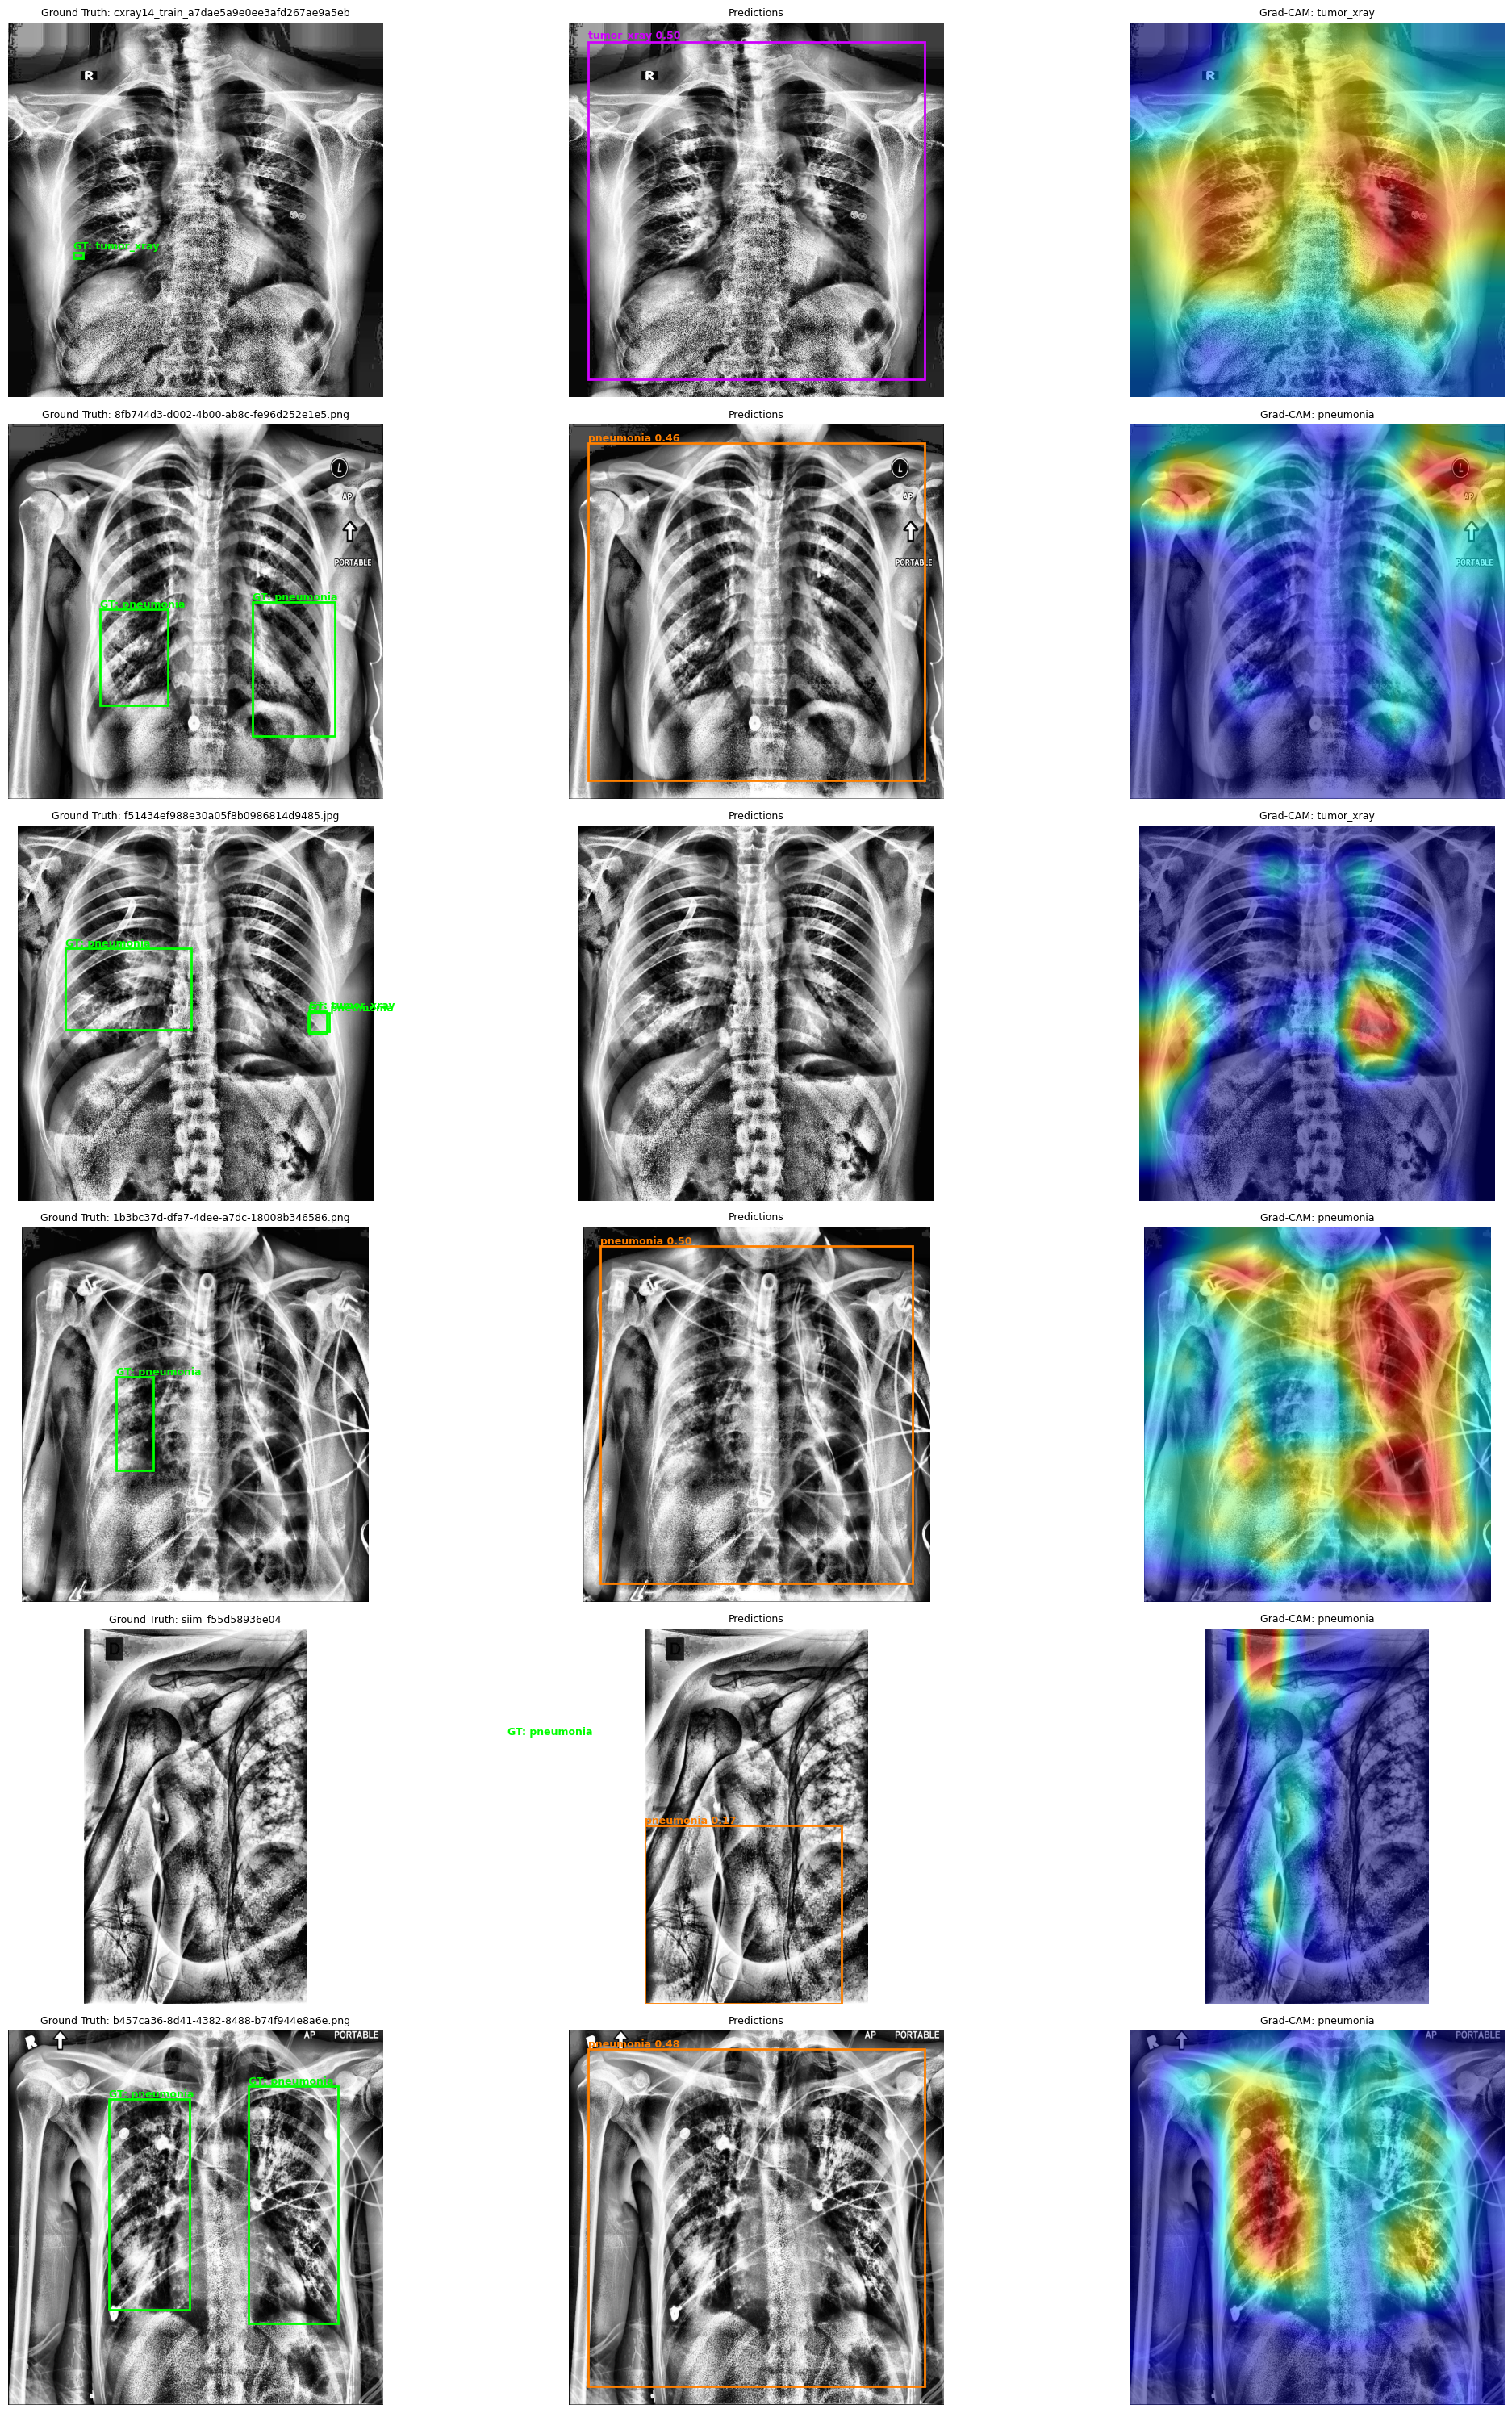

In [21]:
if DET_CKPT.exists() and len(val_keys) > 0:
    det = YOLO(str(DET_CKPT))
    n_show = min(6, len(val_keys))
    fig, axes = plt.subplots(n_show, 3, figsize=(21, 5 * n_show))
    axes = np.atleast_2d(axes)
    if axes.shape[1] == 1: axes = axes.reshape(-1, 3)
    cols = distinctipy.get_colors(NUM_CLASSES, rng=0)

    for i in range(n_show):
        k = val_keys[i]
        ip = df[df["image"] == k]["image_path"].iloc[0]
        img = cv2.imread(ip)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_norm = img_rgb.astype(np.float32) / 255.0

        # Col 1: Ground Truth
        ax_gt = axes[i][0]
        ax_gt.imshow(img_rgb)
        for _, r in df[df["image"] == k].iterrows():
            rect = mpatches.Rectangle((r["xmin"], r["ymin"]),
                r["xmax"]-r["xmin"], r["ymax"]-r["ymin"],
                linewidth=2, edgecolor="lime", facecolor="none")
            ax_gt.add_patch(rect)
            ax_gt.text(r["xmin"], r["ymin"]-5, f"GT: {r['label']}",
                      color="lime", fontsize=9, fontweight="bold")
        ax_gt.set_title(f"Ground Truth: {k[:40]}", fontsize=9); ax_gt.axis("off")

        # Col 2: Predictions
        ax_pred = axes[i][1]
        ax_pred.imshow(img_rgb)
        boxes, scores, labels, cls_probs = predict_ensemble(det, img)
        for (x1, y1, x2, y2), s, l in zip(boxes, scores, labels):
            col = tuple(cols[int(l)])
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor=col, facecolor="none")
            ax_pred.add_patch(rect)
            ax_pred.text(x1, y1-5, f"{CLASS_NAMES[int(l)]} {s:.2f}",
                      color=col, fontsize=9, fontweight="bold")
        ax_pred.set_title("Predictions", fontsize=9); ax_pred.axis("off")

        # Col 3: Grad-CAM Heatmap (for the dominant predicted class)
        ax_cam = axes[i][2]
        gt_labels_for_img = df[df["image"] == k]["label"].unique()
        dominant_class = gt_labels_for_img[0] if len(gt_labels_for_img) > 0 else "pneumonia"
        cam_idx = CLASS_TO_IDX.get(dominant_class, 2)
        heatmap = get_gradcam_heatmap(img, cam_idx)
        if heatmap is not None:
            heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
            cam_overlay = show_cam_on_image(img_norm, heatmap_resized, use_rgb=True)
            ax_cam.imshow(cam_overlay)
        else:
            ax_cam.imshow(img_rgb)
        ax_cam.set_title(f"Grad-CAM: {dominant_class}", fontsize=9); ax_cam.axis("off")

    plt.tight_layout(); plt.show()


## Summary

FinalProjectV4 improvements over V3:
1. **YOLOv12l** — Large backbone for stronger feature extraction (max attention model on T4)
2. **896px** — nearly 2x more pixels than V3 for fuzzy pneumonia borders
3. **RSNA 3-radiologist consensus** — WBF-fused gold-standard boxes
4. **Reduced Mosaic (0.1), added Mixup (0.2)** — better anatomical context
5. **box=12.0, cls=2.0** — massive localization + classification penalty
6. **Grad-CAM heatmaps** — visual "focus area" showing model attention
